In [9]:
import os
import sys
from pathlib import Path

import hydra
import rootutils

# Setup root directory
rootutils.setup_root(__file__ if "__file__" in dir() else os.getcwd(), indicator=".project-root", pythonpath=True)

import torch
import torchvision
from torchvision.transforms import v2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchmetrics.classification import MulticlassConfusionMatrix
from omegaconf import OmegaConf

# Import data components
from src.data.components.transform_subset import TransformSubset

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Model Evaluation Script

This notebook provides comprehensive evaluation tools for models trained with `train.py`:
- Confusion matrices with visualizations
- Per-class metrics (precision, recall, F1-score)
- Per-class loss analysis
- Misclassification analysis
- Comparative analysis across runs

## Configuration

Set the path to your experiment results and configure evaluation parameters.

In [10]:
# Configuration
MODEL_PATH = "../logs/train/SurfaceDefectDetection/Baseline_Max/2026-01-30_08-34-54_cluster_new_data"  # Change to your experiment path
EVAL_PATH = "../logs/eval/SurfaceDefectDetection/baseline_clustered_new_data"
CONFIG_PATH = "../configs"  # Path to your configs directory
CONFIG_NAME = "train.yaml"  # Config file used for training

# Device configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Load Configuration and Data

Load the training configuration and setup data transformations.

In [11]:
test_data_path = os.path.join("../", "data/surface/test")

test_dataset = torchvision.datasets.ImageFolder(root=test_data_path)

class_names = test_dataset.classes
num_classes = len(class_names)

print(f"\nNumber of classes: {num_classes}")
print(f"Class names: {class_names}")

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Test transforms (same as training)
test_transforms = v2.Compose(
    [
        v2.Resize(480, antialias=True),
        v2.CenterCrop(480),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=mean, std=std),
    ])


Number of classes: 10
Class names: ['bend', 'black_stain', 'corrosion', 'crack', 'deformation', 'missing_part', 'no_deficiencies', 'other', 'silicate_stain', 'water_stain']


In [12]:
# Load configuration
with hydra.initialize(version_base="1.3", config_path=CONFIG_PATH):
    cfg = hydra.compose(config_name=CONFIG_NAME)

# Load hyperparameters if available
hyperparams_path = Path(MODEL_PATH) / "summary" / "hyperparameters.yaml"
if hyperparams_path.exists():
    hyperparams = OmegaConf.load(hyperparams_path)
    print("Loaded hyperparameters from experiment")
else:
    hyperparams = cfg
    print("Using default config (hyperparameters.yaml not found)")

print(hyperparams)

Loaded hyperparameters from experiment
{'research_name': 'SurfaceDefectDetection', 'run_name_postfix': 'cluster_new_data', 'run_name': '2026-01-30_08-34-54_cluster_new_data', 'log_path': './logs', 'seed': 42, 'n_runs': 5, 'paths': {'root_dir': '.', 'log_dir': './logs/', 'output_dir': '/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/Baseline_Max/2026-01-30_08-34-54_cluster_new_data', 'work_dir': '/home/lukasb/Documents/NoisyLabelDefectDetection'}, 'trainer': {'_target_': 'lightning.pytorch.trainer.Trainer', 'default_root_dir': '/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/Baseline_Max/2026-01-30_08-34-54_cluster_new_data', 'min_epochs': 10, 'max_epochs': 300, 'accelerator': 'gpu', 'devices': [1], 'check_val_every_n_epoch': 1, 'deterministic': False, 'precision': '16-mixed'}, 'callbacks': {'model_checkpoint': {'_target_': 'lightning.pytorch.callbacks.ModelCheckpoint', 'dirpath': None, 'filename': 'epoch_{epoch:03d}-

## Load Best Model

Load the best model checkpoint from a specific run.

In [13]:
def load_model():
    """Load the best model from a specific run."""
    model = hydra.utils.instantiate(hyperparams.model, num_classes=num_classes)
    checkpoint_path = Path(MODEL_PATH) / "run_5/checkpoints/epoch_074-val_f1_0.6342.ckpt"
    
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Model not found at {checkpoint_path}")
    
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    state = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    
    print(f"Loaded model from: {checkpoint_path}")
    return model

model = load_model()

Loaded model from: ../logs/train/SurfaceDefectDetection/Baseline_Max/2026-01-30_08-34-54_cluster_new_data/run_5/checkpoints/epoch_074-val_f1_0.6342.ckpt


## Generate Predictions on Test Set

Run inference on the test set and collect predictions, targets, and logits.

In [14]:
def get_predictions(model, dataloader, device):
    """Generate predictions and collect all outputs."""
    all_preds = []
    all_targets = []
    all_logits = []
    all_probs = []
    
    model.eval()
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_logits.append(outputs.cpu())
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    
    return {
        'predictions': torch.cat(all_preds).numpy(),
        'targets': torch.cat(all_targets).numpy(),
        'logits': torch.cat(all_logits).numpy(),
        'probabilities': torch.cat(all_probs).numpy()
    }

# Create test dataloader
test_dataset_transformed = TransformSubset(
    test_dataset,
    indices=list(range(len(test_dataset))),
    transform=test_transforms
)

test_loader = torch.utils.data.DataLoader(
    test_dataset_transformed,
    batch_size=hyperparams.data.get("batch_size", 32),
    shuffle=False,
    num_workers=4
)

# Get predictions
print("Generating predictions on test set...")
results = get_predictions(model, test_loader, device)
print(f"Generated predictions for {len(results['predictions'])} samples")


Generating predictions on test set...


Generated predictions for 856 samples


## Confusion Matrix Visualization

Generate and visualize confusion matrices to understand classification patterns.

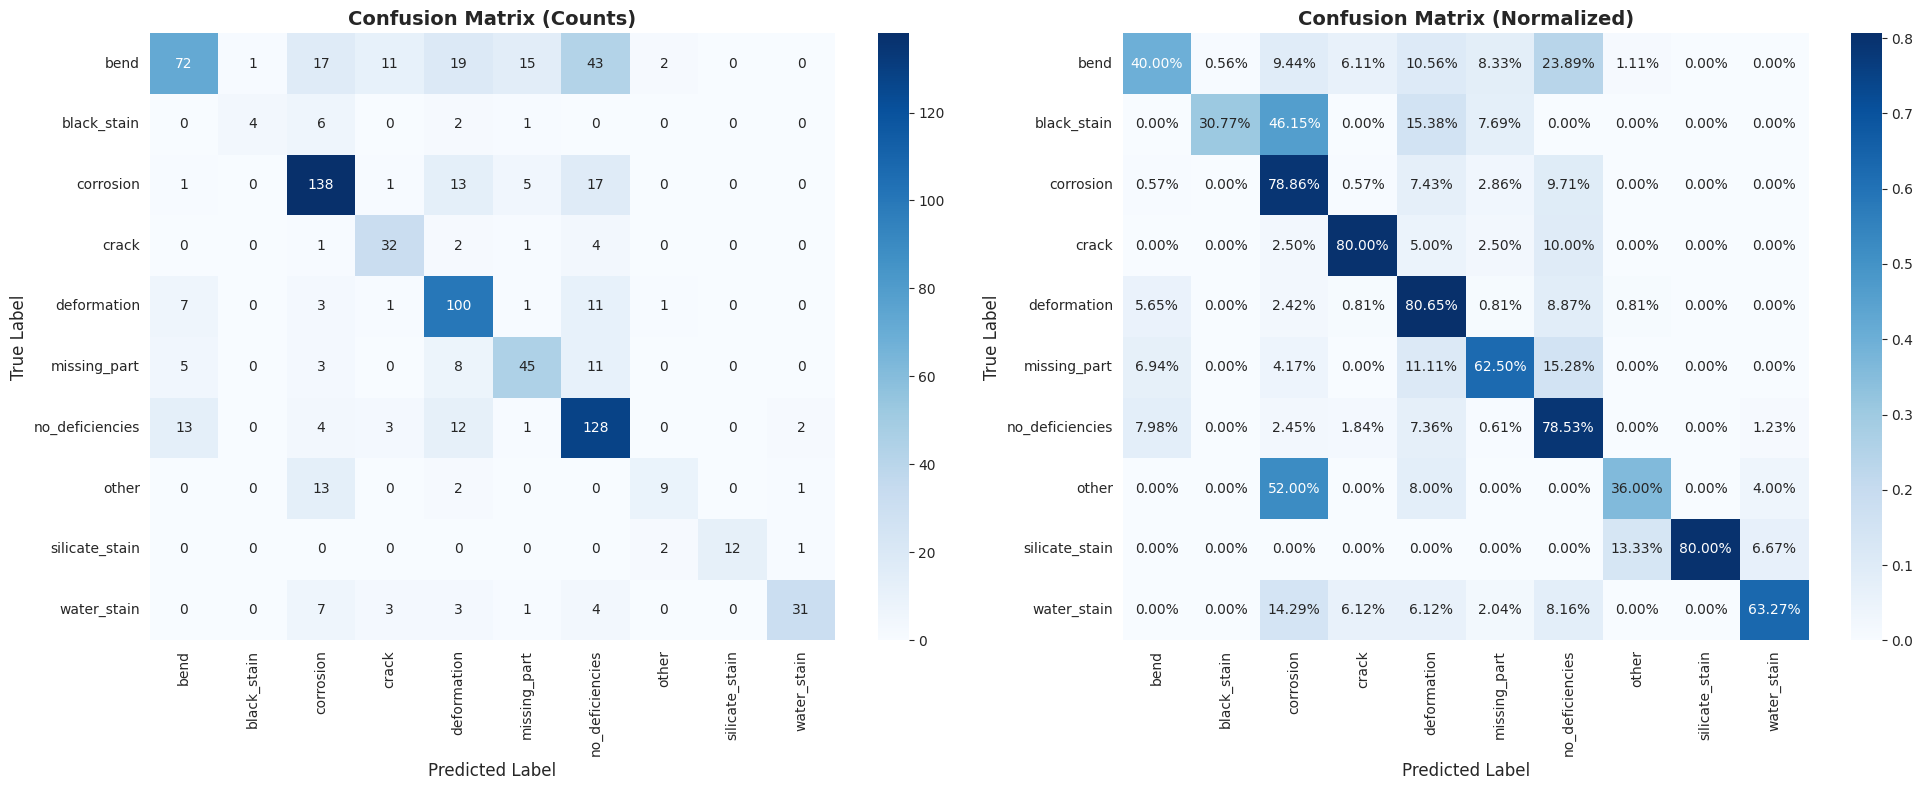

Saved confusion matrix to ../logs/eval/SurfaceDefectDetection/baseline_clustered_new_data/confusion_matrix.png


In [15]:
# Compute confusion matrix
cm = confusion_matrix(results['targets'], results['predictions'])

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix (counts)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Confusion matrix with counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)

# Confusion matrix with percentages
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

# Save confusion matrix
save_path = Path(EVAL_PATH) / "confusion_matrix.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved confusion matrix to {save_path}")

## Per-Class Metrics

Compute and visualize per-class precision, recall, and F1-score.

Classification Report:
                 precision    recall  f1-score     support
bend              0.734694  0.400000  0.517986  180.000000
black_stain       0.800000  0.307692  0.444444   13.000000
corrosion         0.718750  0.788571  0.752044  175.000000
crack             0.627451  0.800000  0.703297   40.000000
deformation       0.621118  0.806452  0.701754  124.000000
missing_part      0.642857  0.625000  0.633803   72.000000
no_deficiencies   0.587156  0.785276  0.671916  163.000000
other             0.642857  0.360000  0.461538   25.000000
silicate_stain    1.000000  0.800000  0.888889   15.000000
water_stain       0.885714  0.632653  0.738095   49.000000
accuracy          0.667056  0.667056  0.667056    0.667056
macro avg         0.726060  0.630564  0.651377  856.000000
weighted avg      0.685755  0.667056  0.656503  856.000000
Macro precission: 0.7184206418251204
Macro recall: 0.6361785447649926
Macro f1: 0.6529770864113827


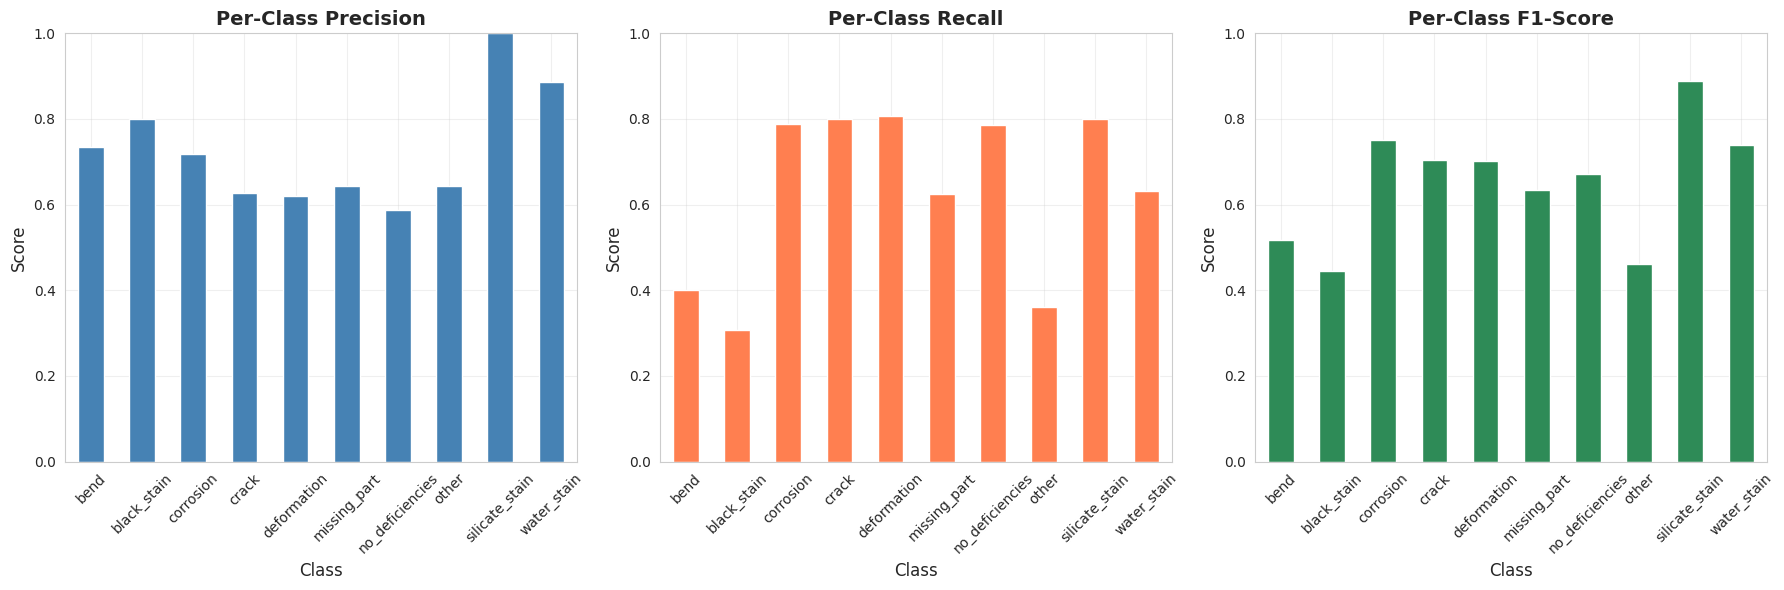

Saved per-class metrics to ../logs/eval/SurfaceDefectDetection/baseline_clustered_new_data/per_class_metrics.png
Saved classification report to ../logs/eval/SurfaceDefectDetection/baseline_clustered_new_data/classification_report.csv


In [16]:
# Generate classification report
report = classification_report(
    results['targets'], 
    results['predictions'], 
    target_names=class_names,
    output_dict=True
)

# Convert to DataFrame for better visualization
report_df = pd.DataFrame(report).transpose()

# Display the report
print("Classification Report:")
print(report_df)

print(f"Macro precission: {report_df['precision'].mean()}")
print(f"Macro recall: {report_df['recall'].mean()}")
print(f"Macro f1: {report_df['f1-score'].mean()}")


# Plot per-class metrics
metrics_df = report_df.iloc[:-3]  # Exclude accuracy, macro avg, weighted avg
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision
metrics_df['precision'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Per-Class Precision', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Recall
metrics_df['recall'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Per-Class Recall', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# F1-Score
metrics_df['f1-score'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Per-Class F1-Score', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Score', fontsize=12)
axes[2].set_xlabel('Class', fontsize=12)
axes[2].set_ylim([0, 1])
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save metrics
save_path = Path(EVAL_PATH) / "per_class_metrics.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved per-class metrics to {save_path}")

# Save classification report
report_path = Path(EVAL_PATH) / "classification_report.csv"
report_df.to_csv(report_path)
print(f"Saved classification report to {report_path}")

## Misclassification Analysis

Identify and analyze the most common misclassifications.

Total misclassified samples: 285 / 856 (33.29%)

Top 10 Most Common Misclassifications:
     true_class predicted_class  count
           bend no_deficiencies     43
           bend     deformation     19
           bend       corrosion     17
      corrosion no_deficiencies     17
           bend    missing_part     15
no_deficiencies            bend     13
          other       corrosion     13
      corrosion     deformation     13
no_deficiencies     deformation     12
           bend           crack     11


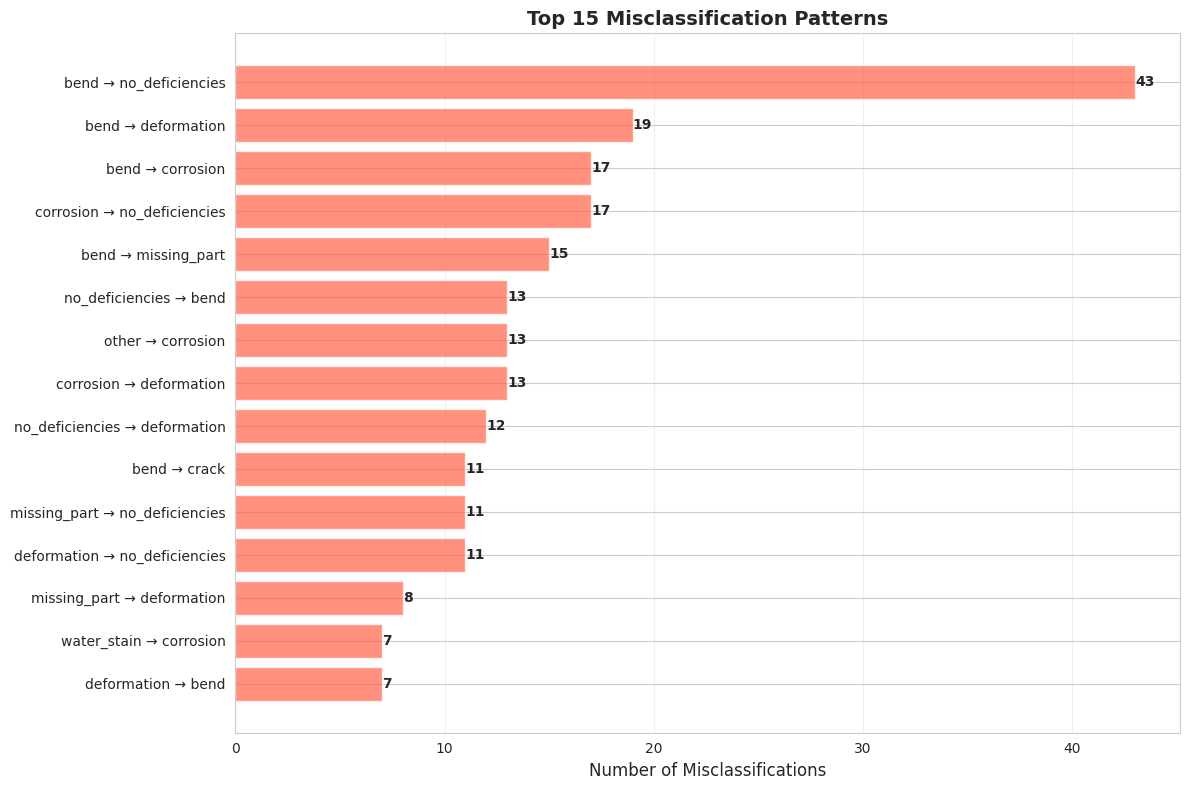


Saved misclassification patterns to ../logs/eval/SurfaceDefectDetection/baseline_clustered_new_data/misclassification_patterns.png
Saved detailed misclassification data to ../logs/eval/SurfaceDefectDetection/baseline_clustered_new_data/misclassifications.csv


In [17]:
# Find misclassified samples
misclassified_mask = results['predictions'] != results['targets']
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassified samples: {len(misclassified_indices)} / {len(results['targets'])} ({100*len(misclassified_indices)/len(results['targets']):.2f}%)")

# Analyze misclassification patterns
misclassification_pairs = []
for idx in misclassified_indices:
    true_class = results['targets'][idx]
    pred_class = results['predictions'][idx]
    confidence = results['probabilities'][idx][pred_class]
    
    misclassification_pairs.append({
        'sample_idx': idx,
        'true_class': class_names[true_class],
        'predicted_class': class_names[pred_class],
        'confidence': confidence,
        'true_class_prob': results['probabilities'][idx][true_class]
    })

misclass_df = pd.DataFrame(misclassification_pairs)

# Count most common misclassification pairs
misclass_counts = misclass_df.groupby(['true_class', 'predicted_class']).size().reset_index(name='count')
misclass_counts = misclass_counts.sort_values('count', ascending=False)

print("\nTop 10 Most Common Misclassifications:")
print(misclass_counts.head(10).to_string(index=False))

# Visualize misclassification patterns
top_n = min(15, len(misclass_counts))
top_misclass = misclass_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(top_misclass))
bars = ax.barh(y_pos, top_misclass['count'], color='tomato', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['true_class']} → {row['predicted_class']}" 
                     for _, row in top_misclass.iterrows()])
ax.invert_yaxis()
ax.set_xlabel('Number of Misclassifications', fontsize=12)
ax.set_title(f'Top {top_n} Misclassification Patterns', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}',
            ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Save misclassification analysis
save_path = Path(EVAL_PATH) / "misclassification_patterns.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nSaved misclassification patterns to {save_path}")

misclass_csv_path = Path(EVAL_PATH) / "misclassifications.csv"
misclass_df.to_csv(misclass_csv_path, index=False)
print(f"Saved detailed misclassification data to {misclass_csv_path}")

## Confidence Distribution Analysis

Analyze prediction confidence for correct vs incorrect predictions.

/tmp/ipykernel_2953132/1394116183.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['Correct', 'Incorrect'], patch_artist=True)


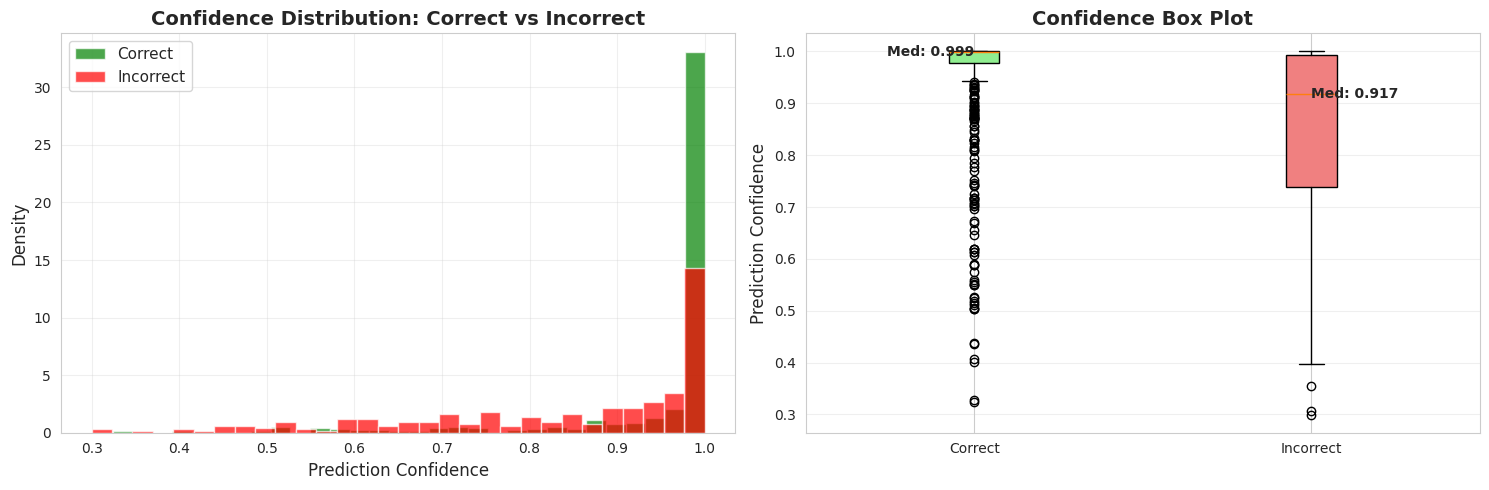

Saved confidence distribution to ../logs/eval/SurfaceDefectDetection/baseline_clustered_new_data/confidence_distribution.png

Confidence Statistics:
Correct predictions - Mean: 0.949, Median: 0.999, Std: 0.119
Incorrect predictions - Mean: 0.845, Median: 0.917, Std: 0.172


In [18]:
# Get max confidence for each prediction
max_confidences = np.max(results['probabilities'], axis=1)
correct_mask = results['predictions'] == results['targets']

correct_confidences = max_confidences[correct_mask]
incorrect_confidences = max_confidences[~correct_mask]

# Plot confidence distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(correct_confidences, bins=30, alpha=0.7, label='Correct', color='green', density=True)
axes[0].hist(incorrect_confidences, bins=30, alpha=0.7, label='Incorrect', color='red', density=True)
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Confidence Distribution: Correct vs Incorrect', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Box plot
box_data = [correct_confidences, incorrect_confidences]
bp = axes[1].boxplot(box_data, labels=['Correct', 'Incorrect'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Prediction Confidence', fontsize=12)
axes[1].set_title('Confidence Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add statistics
axes[1].text(1, np.median(correct_confidences), f'Med: {np.median(correct_confidences):.3f}', 
             ha='right', va='center', fontsize=10, fontweight='bold')
axes[1].text(2, np.median(incorrect_confidences), f'Med: {np.median(incorrect_confidences):.3f}', 
             ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Save confidence distribution
save_path = Path(EVAL_PATH) / "confidence_distribution.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved confidence distribution to {save_path}")

# Print statistics
print(f"\nConfidence Statistics:")
print(f"Correct predictions - Mean: {correct_confidences.mean():.3f}, Median: {np.median(correct_confidences):.3f}, Std: {correct_confidences.std():.3f}")
print(f"Incorrect predictions - Mean: {incorrect_confidences.mean():.3f}, Median: {np.median(incorrect_confidences):.3f}, Std: {incorrect_confidences.std():.3f}")

## Per-Class Confidence Analysis

Analyze prediction confidence for each class separately.

Per-Class Confidence Statistics:
                     mean    median       std       min       max  count
silicate_stain   0.961868  0.999992  0.105157  0.585569  1.000000   15.0
water_stain      0.953171  0.999234  0.095414  0.602882  1.000000   49.0
missing_part     0.937081  0.998112  0.122429  0.437484  1.000000   72.0
no_deficiencies  0.929304  0.997474  0.132085  0.299812  1.000000  163.0
corrosion        0.925498  0.998273  0.152977  0.324238  1.000000  175.0
deformation      0.919566  0.998672  0.157140  0.306746  1.000000  124.0
other            0.914553  0.993263  0.143080  0.495131  1.000000   25.0
crack            0.911273  0.987146  0.130933  0.503311  1.000000   40.0
black_stain      0.871442  0.872507  0.134703  0.602290  0.999999   13.0
bend             0.867824  0.948045  0.162600  0.398225  1.000000  180.0


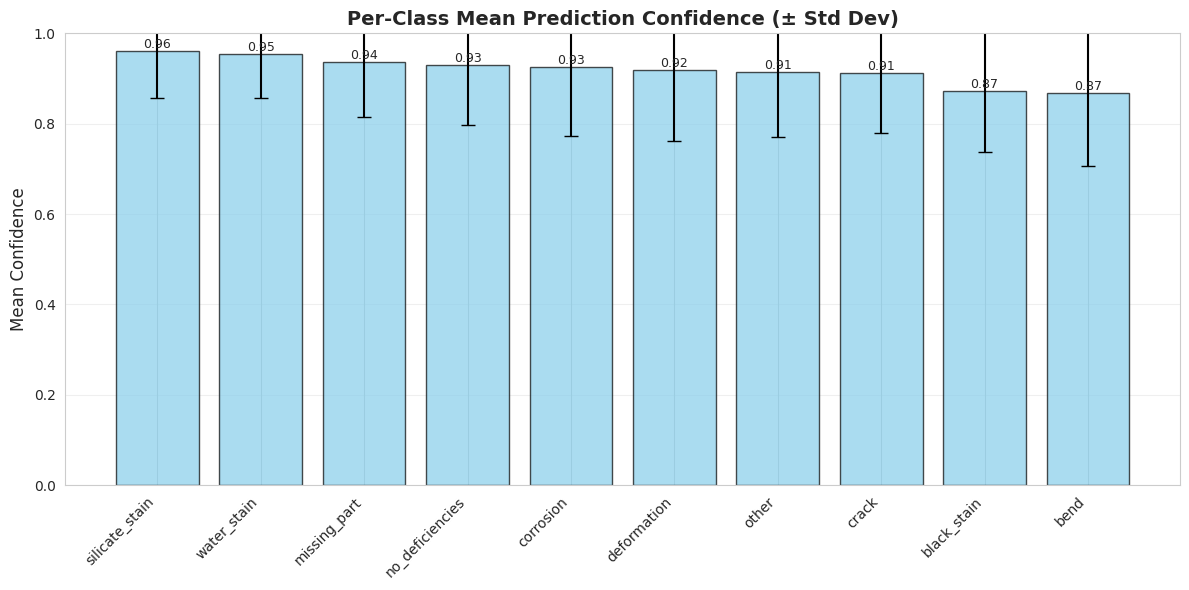


Saved per-class confidence to ../logs/eval/SurfaceDefectDetection/baseline_clustered_new_data/per_class_confidence.png
Saved per-class confidence data to ../logs/eval/SurfaceDefectDetection/baseline_clustered_new_data/per_class_confidence.csv


In [19]:
# Compute per-class confidence statistics
per_class_confidence = {}

for class_idx, class_name in enumerate(class_names):
    class_mask = results['targets'] == class_idx
    class_confidences = max_confidences[class_mask]
    
    if len(class_confidences) > 0:
        per_class_confidence[class_name] = {
            'mean': class_confidences.mean(),
            'median': np.median(class_confidences),
            'std': class_confidences.std(),
            'min': class_confidences.min(),
            'max': class_confidences.max(),
            'count': len(class_confidences)
        }

# Create DataFrame
confidence_stats_df = pd.DataFrame(per_class_confidence).T
confidence_stats_df = confidence_stats_df.sort_values('mean', ascending=False)

print("Per-Class Confidence Statistics:")
print(confidence_stats_df.to_string())

# Plot per-class mean confidence
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(confidence_stats_df))
bars = ax.bar(x_pos, confidence_stats_df['mean'], 
              yerr=confidence_stats_df['std'], 
              capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(confidence_stats_df.index, rotation=45, ha='right')
ax.set_ylabel('Mean Confidence', fontsize=12)
ax.set_title('Per-Class Mean Prediction Confidence (± Std Dev)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, (idx, row)) in enumerate(zip(bars, confidence_stats_df.iterrows())):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Save per-class confidence
save_path = Path(EVAL_PATH) / "per_class_confidence.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nSaved per-class confidence to {save_path}")

confidence_csv_path = Path(EVAL_PATH) / "per_class_confidence.csv"
confidence_stats_df.to_csv(confidence_csv_path)
print(f"Saved per-class confidence data to {confidence_csv_path}")

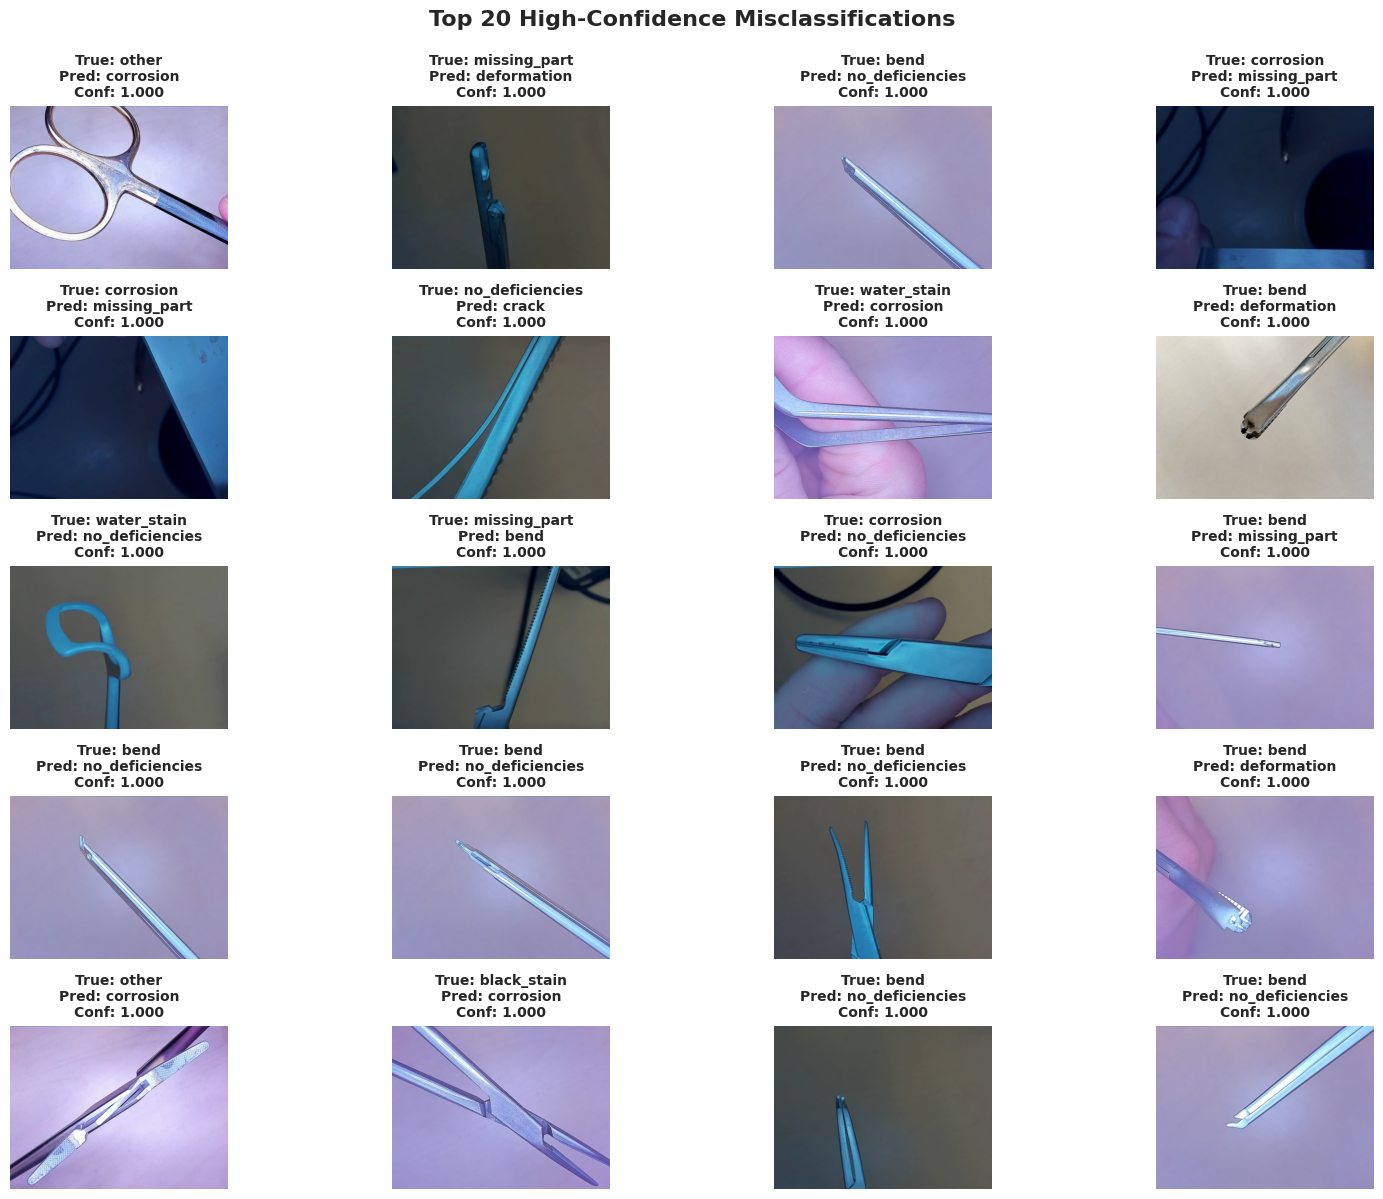


Saved high-confidence errors visualization to ../logs/eval/SurfaceDefectDetection/baseline_clustered_new_data/high_confidence_errors.png

Top 20 High-Confidence Errors:
 sample_idx      true_class predicted_class  confidence  true_class_prob
        779           other       corrosion    1.000000     5.744523e-08
        560    missing_part     deformation    1.000000     1.522803e-12
        131            bend no_deficiencies    1.000000     1.443385e-07
        262       corrosion    missing_part    0.999999     4.385033e-10
        269       corrosion    missing_part    0.999999     8.218661e-08
        717 no_deficiencies           crack    0.999994     1.191189e-06
        848     water_stain       corrosion    0.999994     4.649982e-07
        116            bend     deformation    0.999992     1.787995e-07
        810     water_stain no_deficiencies    0.999976     1.236139e-05
        533    missing_part            bend    0.999973     4.458355e-07
        282       corrosion

In [21]:
# Get high confidence incorrect predictions
high_conf_errors = misclass_df.nlargest(20, 'confidence')

# Create figure for displaying images
fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.ravel()

# Load and display images
for idx, (_, row) in enumerate(high_conf_errors.iterrows()):
    sample_idx = row['sample_idx']
    
    # Get the image path
    img_path = test_dataset.imgs[sample_idx][0]
    img = plt.imread(img_path)
    
    # Display image
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    # Create title with error information
    title = f"True: {row['true_class']}\n"
    title += f"Pred: {row['predicted_class']}\n"
    title += f"Conf: {row['confidence']:.3f}"
    axes[idx].set_title(title, fontsize=10, fontweight='bold')

plt.suptitle('Top 20 High-Confidence Misclassifications', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Save the figure
save_path = Path(EVAL_PATH) / "high_confidence_errors.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nSaved high-confidence errors visualization to {save_path}")

# Print detailed information
print("\nTop 20 High-Confidence Errors:")
print(high_conf_errors[['sample_idx', 'true_class', 'predicted_class', 'confidence', 'true_class_prob']].to_string(index=False))